### Setup

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

import sys
sys.path.insert(0, "/content/drive/MyDrive/cs209b/project")

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)

from helper import *

# Point all path constants at Drive
ROOT, ORIG_DIR, DATA_DIR, OHLCV_DIR = set_root("/content/drive/MyDrive/cs209b/project")

Mounted at /content/drive
ROOT      : /content/drive/MyDrive/cs209b/project
ORIG_DIR  : /content/drive/MyDrive/cs209b/project/EDA/original_data
DATA_DIR  : /content/drive/MyDrive/cs209b/project/EDA/data
OHLCV_DIR : /content/drive/MyDrive/cs209b/project/EDA/data/local_ohlcv_10y_full


### Load & overview expanded dataset

In [2]:
df = load_expanded(DATA_DIR / "analyst_ratings_expanded_local.csv")

In [3]:
df.head(3)

,title,date,stock,url,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,...,t_minus_10_open,t_minus_10_high,t_minus_10_low,t_minus_10_close,t_minus_10_volume,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0.0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 14:30:00+00:00,A,https://www.benzinga.com/news/20/06/16190091/s...,89.82,91.739998,89.820000,91.139999,2227500.0,90.650002,...,81.720001,82.190002,80.459999,80.750000,2576500.0,89.309998,90.589996,89.059998,90.290001,1804700.0
1.0,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 14:45:00+00:00,A,https://www.benzinga.com/news/20/06/16170189/s...,90.00,90.629997,89.110001,90.290001,1682800.0,88.040001,...,83.230003,83.540001,81.889999,81.970001,2099200.0,89.820000,91.739998,89.820000,91.139999,2227500.0
2.0,71 Biggest Movers From Friday,2020-05-26 08:30:00+00:00,A,https://www.benzinga.com/news/20/05/16103463/7...,85.00,87.669998,84.199997,84.980003,5063100.0,81.720001,...,79.599998,81.989998,79.500000,81.269997,1691600.0,86.300003,86.480003,84.370003,86.180000,1917600.0


In [4]:
eda_expanded_overview(df)

Shape         : (849709, 59)
Date range    : 2010-07-24  →  2020-06-11
Unique tickers: 3,580

Columns with nulls:
url    48599


### Rows per year

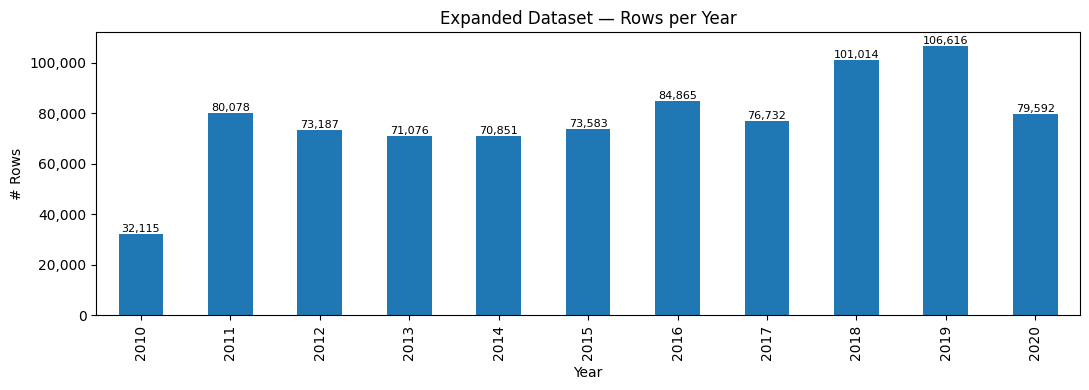

In [5]:
plot_yearly_counts(df, title="Expanded Dataset — Rows per Year")

### Ticker coverage

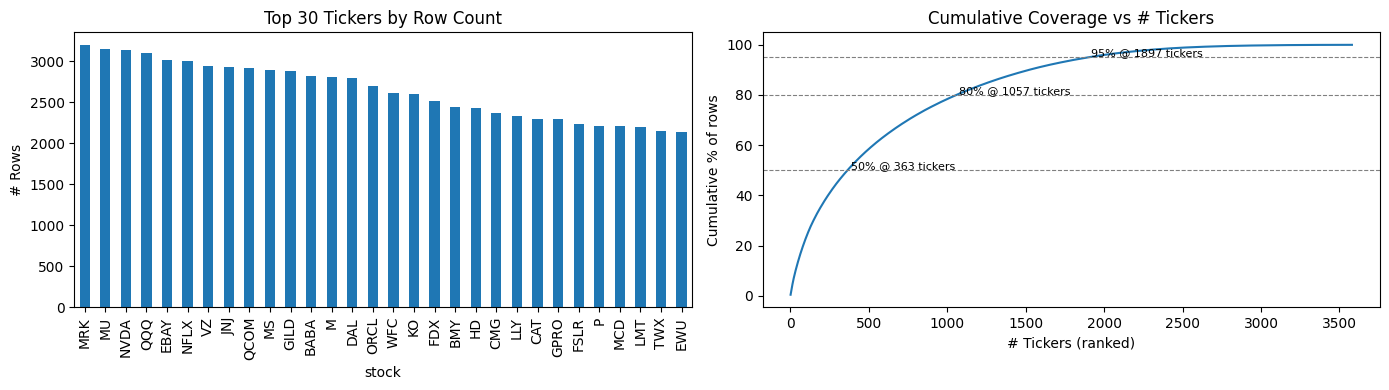

  ≥ 100 rows : 1797 tickers  (93.9% of all rows)
  ≥ 250 rows :  973 tickers  (77.6% of all rows)
  ≥ 500 rows :  462 tickers  (56.3% of all rows)
  ≥1000 rows :  167 tickers  (32.4% of all rows)


In [6]:
plot_ticker_coverage(df)

### OHLCV window shape

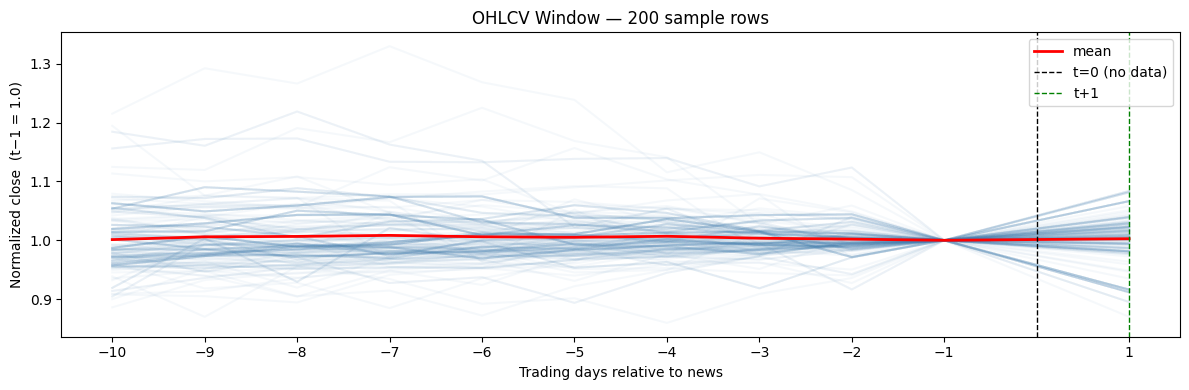

In [7]:
plot_ohlcv_window(df)

### Next-day return

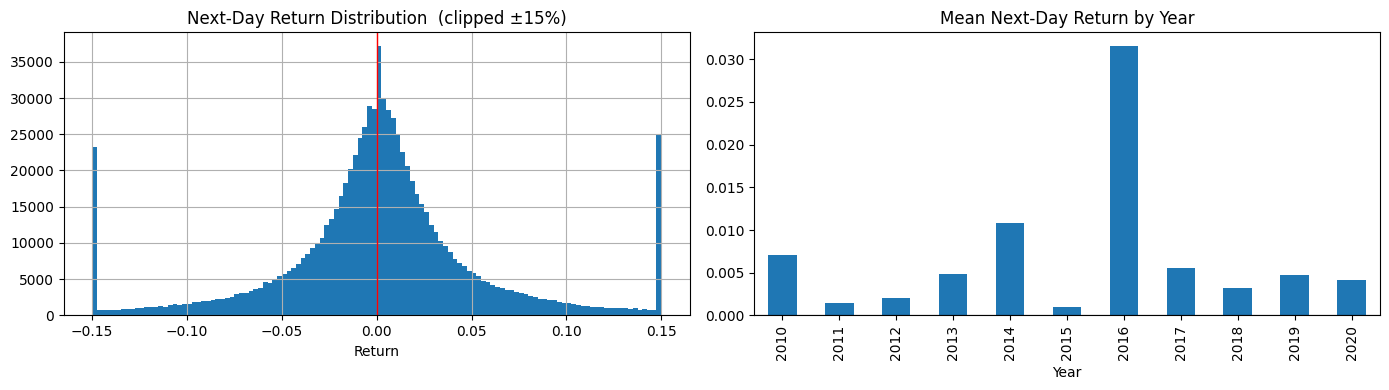

count    849709.0000
mean          0.0070
std           0.9352
min          -0.9974
25%          -0.0206
50%           0.0014
75%           0.0241
max         384.5852
dtype: float64


In [8]:
ret = plot_next_day_return(df)

### Load raw news & compare sources

In [9]:
ar = load_news_csv(ORIG_DIR / "raw_analyst_ratings.csv")
ph = load_news_csv(ORIG_DIR / "raw_partner_headlines.csv")
eda_raw_news(ar, ph, df)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/cs209b/project/EDA/original_data/raw_analyst_ratings.csv'

### Local OHLCV files

In [10]:
eda_ohlcv_files(ar)

NameError: name 'ar' is not defined

### Testing on AAPL

AAPL  total=100  in_2010-2020=45  {'AMC': 97, 'BMO': 3}


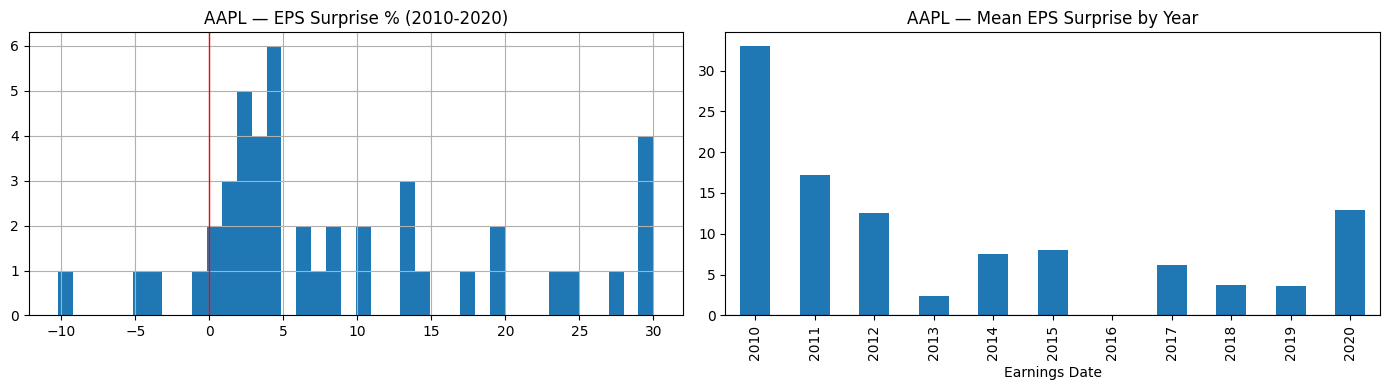

In [11]:
ed = yf_probe_earnings_dates("AAPL", limit=60)
plot_earnings_dates(ed, "AAPL")

In [12]:
top50 = df["stock"].value_counts().head(50).index.tolist()
# cov = yf_coverage_test(top50)
# cov.head(3)

In [ ]:
yf_probe_info(["QQQ"])

In [13]:
# see if QQQ exist in the df, it should not since it's an ETF, not a stock
df[df["stock"] == "QQQ"].head(2)

,title,date,stock,url,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,...,t_minus_10_open,t_minus_10_high,t_minus_10_low,t_minus_10_close,t_minus_10_volume,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
1054626.0,Afternoon Market Stats in 5 Minutes,2020-06-10 16:12:00+00:00,QQQ,https://www.benzinga.com/markets/20/06/1622357...,240.660004,244.179993,240.470001,243.300003,35046300.0,239.539993,...,228.690002,230.410004,223.940002,230.289993,55665600.0,242.160004,243.589996,233.960007,234.020004,72919400.0
1054627.0,Morning Market Stats in 5 Minutes,2020-06-10 14:22:00+00:00,QQQ,https://www.benzinga.com/markets/20/06/1622174...,240.660004,244.179993,240.470001,243.300003,35046300.0,239.539993,...,228.690002,230.410004,223.940002,230.289993,55665600.0,242.160004,243.589996,233.960007,234.020004,72919400.0


### Data cleaning, filter only stocks

In [14]:
tickers = df["stock"].unique().tolist()
len(tickers)

3580

In [15]:
# if the data already exist, load it, otherwise fetch and save
import pandas as pd

qt = fetch_quote_types(tickers, DATA_DIR / "ticker_quotetype.csv")
print(qt["quoteType"].value_counts())

equity_tickers = qt.loc[qt["quoteType"] == "EQUITY", "symbol"].tolist()
df_eq = df[df["stock"].isin(equity_tickers)].reset_index(drop=True)
print(
    f"\nRows before: {len(df):,}  after: {len(df_eq):,}  dropped: {len(df) - len(df_eq):,}"
)

  Resuming: 3580/3580 already done
  Done: 3580 tickers -> /content/drive/MyDrive/cs209b/project/EDA/data/ticker_quotetype.csv
quoteType
EQUITY        2122
ETF            833
MUTUALFUND     181
Name: count, dtype: int64

Rows before: 849,709  after: 653,926  dropped: 195,783


In [22]:
# Sanity check on equity filter
print("=== Quote type distribution in original ===")
print(qt["quoteType"].value_counts())

=== Quote type distribution in original ===
quoteType
EQUITY        2122
ETF            833
MUTUALFUND     181
Name: count, dtype: int64


In [23]:
print("\n=== Unique tickers before vs after ===")
print(f"  Original : {df['stock'].nunique():,} tickers")
print(f"  Equities : {df_eq['stock'].nunique():,} tickers")


=== Unique tickers before vs after ===
  Original : 3,580 tickers
  Equities : 2,122 tickers


In [24]:
print("\n=== Any non-equity tickers leaked through? ===")
leaked = set(df_eq["stock"].unique()) - set(equity_tickers)
print(f"  Leaked tickers: {len(leaked)}")


=== Any non-equity tickers leaked through? ===
  Leaked tickers: 0


In [27]:
print("\n=== Null check ===")
print(df_eq.isnull().sum())


=== Null check ===
title                    0
date                     0
stock                    0
url                  36878
t_minus_1_open           0
t_minus_1_high           0
t_minus_1_low            0
t_minus_1_close          0
t_minus_1_volume         0
t_minus_2_open           0
t_minus_2_high           0
t_minus_2_low            0
t_minus_2_close          0
t_minus_2_volume         0
t_minus_3_open           0
t_minus_3_high           0
t_minus_3_low            0
t_minus_3_close          0
t_minus_3_volume         0
t_minus_4_open           0
t_minus_4_high           0
t_minus_4_low            0
t_minus_4_close          0
t_minus_4_volume         0
t_minus_5_open           0
t_minus_5_high           0
t_minus_5_low            0
t_minus_5_close          0
t_minus_5_volume         0
t_minus_6_open           0
t_minus_6_high           0
t_minus_6_low            0
t_minus_6_close          0
t_minus_6_volume         0
t_minus_7_open           0
t_minus_7_high           0
t_minus_

In [29]:
print("\n=== Sample rows ===")
df_eq.head(3)


=== Sample rows ===


,title,date,stock,url,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,...,t_minus_10_open,t_minus_10_high,t_minus_10_low,t_minus_10_close,t_minus_10_volume,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 14:30:00+00:00,A,https://www.benzinga.com/news/20/06/16190091/s...,89.82,91.739998,89.820000,91.139999,2227500.0,90.650002,...,81.720001,82.190002,80.459999,80.750000,2576500.0,89.309998,90.589996,89.059998,90.290001,1804700.0
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 14:45:00+00:00,A,https://www.benzinga.com/news/20/06/16170189/s...,90.00,90.629997,89.110001,90.290001,1682800.0,88.040001,...,83.230003,83.540001,81.889999,81.970001,2099200.0,89.820000,91.739998,89.820000,91.139999,2227500.0
2,71 Biggest Movers From Friday,2020-05-26 08:30:00+00:00,A,https://www.benzinga.com/news/20/05/16103463/7...,85.00,87.669998,84.199997,84.980003,5063100.0,81.720001,...,79.599998,81.989998,79.500000,81.269997,1691600.0,86.300003,86.480003,84.370003,86.180000,1917600.0


In [31]:
# Filter to equities only and save
df_eq.to_csv(DATA_DIR / "expanded_equities.csv", index=False)

In [32]:
df_eq.head(3)

,title,date,stock,url,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,...,t_minus_10_open,t_minus_10_high,t_minus_10_low,t_minus_10_close,t_minus_10_volume,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 14:30:00+00:00,A,https://www.benzinga.com/news/20/06/16190091/s...,89.82,91.739998,89.820000,91.139999,2227500.0,90.650002,...,81.720001,82.190002,80.459999,80.750000,2576500.0,89.309998,90.589996,89.059998,90.290001,1804700.0
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 14:45:00+00:00,A,https://www.benzinga.com/news/20/06/16170189/s...,90.00,90.629997,89.110001,90.290001,1682800.0,88.040001,...,83.230003,83.540001,81.889999,81.970001,2099200.0,89.820000,91.739998,89.820000,91.139999,2227500.0
2,71 Biggest Movers From Friday,2020-05-26 08:30:00+00:00,A,https://www.benzinga.com/news/20/05/16103463/7...,85.00,87.669998,84.199997,84.980003,5063100.0,81.720001,...,79.599998,81.989998,79.500000,81.269997,1691600.0,86.300003,86.480003,84.370003,86.180000,1917600.0


In [33]:
# Fetch sector & industry for equity tickers
meta = fetch_ticker_metadata(equity_tickers, DATA_DIR / "ticker_metadata.csv")
meta.head(3)

  Resuming: 2122/2122 already done
  Done: 2122 tickers -> /content/drive/MyDrive/cs209b/project/EDA/data/ticker_metadata.csv


,symbol,sector,industry
0,A,Healthcare,Diagnostics & Research
1,AAME,Financial Services,Insurance - Life
2,AAOI,Technology,Communication Equipment


In [34]:
print("=== Shape ===")
print(meta.shape)

=== Shape ===
(2122, 3)


In [35]:
print("\n=== Null counts ===")
print(meta.isnull().sum())


=== Null counts ===
symbol       0
sector      14
industry    14
dtype: int64


In [36]:
print("\n=== Sector distribution ===")
print(meta["sector"].value_counts())


=== Sector distribution ===
sector
Financial Services        596
Industrials               270
Technology                246
Healthcare                231
Consumer Cyclical         199
Basic Materials           114
Energy                    112
Real Estate               107
Consumer Defensive         95
Communication Services     83
Utilities                  55
Name: count, dtype: int64


In [37]:
print("\n=== Industry count per sector ===")
print(meta.groupby("sector")["industry"].nunique().sort_values(ascending=False))


=== Industry count per sector ===
sector
Industrials               24
Consumer Cyclical         23
Financial Services        15
Basic Materials           14
Technology                12
Real Estate               12
Consumer Defensive        12
Healthcare                11
Energy                     8
Communication Services     7
Utilities                  6
Name: industry, dtype: int64


In [38]:
# Join metadata onto equities dataset
df_eq_join = df_eq.merge(meta, left_on="stock", right_on="symbol", how="left").drop(columns="symbol")
df_eq_join.to_csv(DATA_DIR / "expanded_equities.csv", index=False)

In [42]:
print("=== Shape ===")
print(df_eq_join.shape)

=== Shape ===
(653926, 61)


In [43]:
print("\n=== Null counts ===")
print(df_eq_join.isnull().sum())


=== Null counts ===
title                  0
date                   0
stock                  0
url                36878
t_minus_1_open         0
                   ...  
t_plus_1_low           0
t_plus_1_close         0
t_plus_1_volume        0
sector              2941
industry            2941
Length: 61, dtype: int64


In [44]:
print("\n=== Tickers with missing sector/industry ===")
missing = df_eq_join[df_eq_join["sector"].isnull()]["stock"].unique()
print(f"  {len(missing)} tickers: {missing}")


=== Tickers with missing sector/industry ===
  14 tickers: ['BBBY' 'BMS' 'BPOPM' 'DDT' 'FISV' 'HOVNP' 'IPB' 'KEYW' 'MGR' 'MHNC'
 'POWR' 'PSLV' 'SPPP' 'SVA']


In [46]:
df_eq_join_dropna = df_eq_join.dropna(subset=["sector", "industry"]).reset_index(drop=True)
df_eq_join_dropna.to_csv(DATA_DIR / "expanded_equities.csv", index=False)


After drop: (650985, 61)


In [51]:
df_eq_join_dropna.shape

(650985, 61)

In [52]:
print("\n=== Null counts (non-zero only) ===")
nulls = df_eq_join_dropna.isnull().sum()
print(nulls[nulls > 0])


=== Null counts (non-zero only) ===
url    36698
dtype: int64


In [53]:
print("\n=== Sector distribution ===")
print(df_eq_join_dropna["sector"].value_counts())


=== Sector distribution ===
sector
Healthcare                106637
Technology                100410
Consumer Cyclical          95494
Industrials                87468
Financial Services         77710
Consumer Defensive         41373
Energy                     36903
Basic Materials            35961
Communication Services     30566
Real Estate                21203
Utilities                  17260
Name: count, dtype: int64


In [54]:
df_eq_join_dropna[["stock", "title", "date", "sector", "industry"]].head(5)

,stock,title,date,sector,industry
0,A,Stocks That Hit 52-Week Highs On Friday,2020-06-05 14:30:00+00:00,Healthcare,Diagnostics & Research
1,A,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 14:45:00+00:00,Healthcare,Diagnostics & Research
2,A,71 Biggest Movers From Friday,2020-05-26 08:30:00+00:00,Healthcare,Diagnostics & Research
3,A,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22 16:45:00+00:00,Healthcare,Diagnostics & Research
4,A,B of A Securities Maintains Neutral on Agilent...,2020-05-22 15:38:00+00:00,Healthcare,Diagnostics & Research


In [47]:
df_eq_join_dropna.columns

Index(['title', 'date', 'stock', 'url', 't_minus_1_open', 't_minus_1_high',
       't_minus_1_low', 't_minus_1_close', 't_minus_1_volume',
       't_minus_2_open', 't_minus_2_high', 't_minus_2_low', 't_minus_2_close',
       't_minus_2_volume', 't_minus_3_open', 't_minus_3_high', 't_minus_3_low',
       't_minus_3_close', 't_minus_3_volume', 't_minus_4_open',
       't_minus_4_high', 't_minus_4_low', 't_minus_4_close',
       't_minus_4_volume', 't_minus_5_open', 't_minus_5_high', 't_minus_5_low',
       't_minus_5_close', 't_minus_5_volume', 't_minus_6_open',
       't_minus_6_high', 't_minus_6_low', 't_minus_6_close',
       't_minus_6_volume', 't_minus_7_open', 't_minus_7_high', 't_minus_7_low',
       't_minus_7_close', 't_minus_7_volume', 't_minus_8_open',
       't_minus_8_high', 't_minus_8_low', 't_minus_8_close',
       't_minus_8_volume', 't_minus_9_open', 't_minus_9_high', 't_minus_9_low',
       't_minus_9_close', 't_minus_9_volume', 't_minus_10_open',
       't_minus_10_hig

In [55]:
df_eq_join_dropna.to_parquet(DATA_DIR / "expanded_equities.parquet", index=False)
print("Saved to parquet")

Saved to parquet


In [99]:
# test reload
df_eq_join_dropna = pd.read_parquet(DATA_DIR / "expanded_equities.parquet")

In [100]:
df_eq_join_dropna.head(3)

,title,date,stock,url,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,...,t_minus_10_low,t_minus_10_close,t_minus_10_volume,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume,sector,industry
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 14:30:00+00:00,A,https://www.benzinga.com/news/20/06/16190091/s...,89.82,91.739998,89.820000,91.139999,2227500.0,90.650002,...,80.459999,80.750000,2576500.0,89.309998,90.589996,89.059998,90.290001,1804700.0,Healthcare,Diagnostics & Research
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 14:45:00+00:00,A,https://www.benzinga.com/news/20/06/16170189/s...,90.00,90.629997,89.110001,90.290001,1682800.0,88.040001,...,81.889999,81.970001,2099200.0,89.820000,91.739998,89.820000,91.139999,2227500.0,Healthcare,Diagnostics & Research
2,71 Biggest Movers From Friday,2020-05-26 08:30:00+00:00,A,https://www.benzinga.com/news/20/05/16103463/7...,85.00,87.669998,84.199997,84.980003,5063100.0,81.720001,...,79.500000,81.269997,1691600.0,86.300003,86.480003,84.370003,86.180000,1917600.0,Healthcare,Diagnostics & Research


In [101]:
# Fetch earnings dates for all equity tickers
earn = fetch_earnings_all(equity_tickers, DATA_DIR / "earnings_dates.csv")
earn.head(5)

  Resuming: 2122/2122 tickers already attempted
  Done: 129,627 records for 1819 tickers -> /content/drive/MyDrive/cs209b/project/EDA/data/earnings_dates.csv


,symbol,earnings_date,eps_estimate,reported_eps,surprise_pct
0,A,2026-05-27 20:00:00+00:00,1.41,NaN,NaN
1,A,2026-02-25 21:00:00+00:00,1.24,1.07,-13.72
2,A,2025-11-24 21:00:00+00:00,1.58,1.59,0.37
3,A,2025-08-27 20:00:00+00:00,1.37,1.37,0.17
4,A,2025-05-28 20:00:00+00:00,1.26,1.31,3.62


In [102]:
earn.columns

Index(['symbol', 'earnings_date', 'eps_estimate', 'reported_eps',
       'surprise_pct'],
      dtype='object')

In [103]:
# Build stock-centric OHLCV dataset (deduplicated, no news columns)
ohlcv_cols = [c for c in df_eq_join_dropna.columns if c.startswith("t_")]
keep_cols = ["stock", "date"] + ohlcv_cols + ["sector", "industry"]

In [104]:
# Normalize date to date-only, deduplicate
stock_ohlcv = (
    df_eq_join_dropna[keep_cols]
    .assign(date=pd.to_datetime(df_eq_join_dropna["date"]).dt.normalize().dt.tz_localize(None))
    .drop_duplicates(subset=["stock", "date"])
    .sort_values(["stock", "date"])
    .reset_index(drop=True)
)
print(f"After dedup: {stock_ohlcv.shape}")
print(f"Sample dates: {stock_ohlcv['date'].head(3).tolist()}")

After dedup: (381047, 59)
Sample dates: [Timestamp('2010-08-16 00:00:00'), Timestamp('2010-08-17 00:00:00'), Timestamp('2010-08-25 00:00:00')]


In [105]:
stock_ohlcv.head(3)

,stock,date,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,t_minus_2_high,t_minus_2_low,...,t_minus_10_low,t_minus_10_close,t_minus_10_volume,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume,sector,industry
0,A,2010-08-16,19.592276,19.921316,19.527897,19.563662,3420906.0,19.778255,19.871244,19.606581,...,20.171675,20.615166,4052383.0,20.565092,21.123034,20.329041,20.944206,10206518.0,Healthcare,Diagnostics & Research
1,A,2010-08-17,19.391989,19.799713,19.313305,19.427753,4635908.0,19.592276,19.921316,19.527897,...,19.885551,19.914164,5927800.0,20.979971,21.216022,20.793991,21.058655,4255512.0,Healthcare,Diagnostics & Research
2,A,2010-08-25,19.685265,19.792561,19.377682,19.570814,4102850.0,20.557940,20.593704,19.971388,...,20.014305,20.185980,3952426.0,19.942776,20.121601,19.663805,19.678112,4125778.0,Healthcare,Diagnostics & Research


In [124]:
# Normalize earnings date to date-only for join key
earn_join = earn.copy()
earn_join["date"] = pd.to_datetime(earn_join["earnings_date"], utc=True).dt.normalize().dt.tz_localize(None)
earn_join = earn_join.drop(columns="earnings_date")

In [125]:
earn_join.head(3)

,symbol,eps_estimate,reported_eps,surprise_pct,date
0,A,1.41,NaN,NaN,2026-05-27
1,A,1.24,1.07,-13.72,2026-02-25
2,A,1.58,1.59,0.37,2025-11-24


In [126]:
print(f"Sample dates: {earn_join['date'].head(3).tolist()}")

Sample dates: [Timestamp('2026-05-27 00:00:00'), Timestamp('2026-02-25 00:00:00'), Timestamp('2025-11-24 00:00:00')]


In [127]:
# Check earnings vs stock_ohlcv overlap before joining
earn_keys = set(zip(earn_join["symbol"], earn_join["date"]))
ohlcv_keys = set(zip(stock_ohlcv["stock"], stock_ohlcv["date"]))

In [128]:
matched = earn_keys & ohlcv_keys

In [129]:
print(f"Total earnings records : {len(earn_join):,}")
print(f"Unique stock+date in earnings  : {len(earn_keys):,}")
print(f"Unique stock+date in stock_ohlcv: {len(ohlcv_keys):,}")
print(f"Matched (earnings date in ohlcv): {len(matched):,}")
print(f"Match rate: {len(matched)/len(earn_keys)*100:.1f}%")

Total earnings records : 129,627
Unique stock+date in earnings  : 129,167
Unique stock+date in stock_ohlcv: 381,047
Matched (earnings date in ohlcv): 43,249
Match rate: 33.5%


In [130]:
# Inner join earnings onto stock_ohlcv
earning_final = stock_ohlcv.merge(
    earn_join.rename(columns={"symbol": "stock"}),
    on=["stock", "date"],
    how="inner"
)

In [131]:
print(f"Final shape: {earning_final.shape}")
print(f"Rows with earnings: {earning_final['eps_estimate'].notna().sum():,}")
earning_final.head(3)

Final shape: (43268, 62)
Rows with earnings: 42,998


,stock,date,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,t_minus_2_high,t_minus_2_low,...,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume,sector,industry,eps_estimate,reported_eps,surprise_pct
0,A,2010-08-16,19.592276,19.921316,19.527897,19.563662,3420906.0,19.778255,19.871244,19.606581,...,20.565092,21.123034,20.329041,20.944206,10206518.0,Healthcare,Diagnostics & Research,0.48,0.54,12.50
1,A,2010-11-12,24.892704,25.608011,24.663805,25.557940,5294925.0,25.364807,25.507868,24.957083,...,26.137339,26.194565,25.586552,25.894135,6752060.0,Healthcare,Diagnostics & Research,0.60,0.65,8.52
2,A,2011-02-14,31.309013,32.296139,31.223175,32.203148,6201668.0,30.915594,31.480686,30.450644,...,32.038628,32.188843,30.500715,30.507868,10243286.0,Healthcare,Diagnostics & Research,0.57,0.60,5.33


In [132]:
earning_final.to_parquet(DATA_DIR / "earnings_ONLY_joint.parquet", index=False)
earning_final.to_csv(DATA_DIR / "earnings_ONLY_joint.csv", index=False)

In [133]:
earning_final

,stock,date,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,t_minus_2_high,t_minus_2_low,...,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume,sector,industry,eps_estimate,reported_eps,surprise_pct
0,A,2010-08-16,19.592276,19.921316,19.527897,19.563662,3420906.0,19.778255,19.871244,19.606581,...,20.565092,21.123034,20.329041,20.944206,10206518.0,Healthcare,Diagnostics & Research,0.48,0.54,12.50
1,A,2010-11-12,24.892704,25.608011,24.663805,25.557940,5294925.0,25.364807,25.507868,24.957083,...,26.137339,26.194565,25.586552,25.894135,6752060.0,Healthcare,Diagnostics & Research,0.60,0.65,8.52
2,A,2011-02-14,31.309013,32.296139,31.223175,32.203148,6201668.0,30.915594,31.480686,30.450644,...,32.038628,32.188843,30.500715,30.507868,10243286.0,Healthcare,Diagnostics & Research,0.57,0.60,5.33
3,A,2011-05-13,35.650928,36.187412,35.329041,36.001431,5065373.0,36.130184,36.230328,35.522175,...,37.331902,37.911301,37.246067,37.424892,7251706.0,Healthcare,Diagnostics & Research,0.65,0.74,14.03
4,A,2011-08-15,25.000000,26.423462,24.613733,25.901287,13183979.0,22.975679,25.021460,22.789700,...,26.444921,27.274677,25.772532,26.201717,10777182.0,Healthcare,Diagnostics & Research,0.73,0.77,5.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43263,TLF,2014-05-12,9.250000,9.420000,9.250000,9.400000,9500.0,9.200000,9.350000,9.200000,...,9.480000,9.700000,9.050000,9.600000,8600.0,Consumer Cyclical,Specialty Retail,0.17,0.18,5.88
43264,TLF,2014-08-07,9.430000,9.500000,9.400000,9.460000,10800.0,9.370000,9.450000,9.350000,...,9.510000,9.510000,9.280000,9.460000,38700.0,Consumer Cyclical,Specialty Retail,0.19,0.17,-10.53
43265,TLOG,2014-11-05,3.875000,3.990000,3.800000,3.900000,23498.0,3.800000,3.940000,3.791000,...,3.850000,3.860000,3.620000,3.830000,66353.0,Healthcare,Biotechnology,-0.36,-0.37,-2.25
43266,TLOG,2015-02-26,4.980000,4.980000,4.740000,4.870000,31559.0,5.060000,5.070000,4.830000,...,4.960000,4.960000,4.550000,4.820000,30559.0,Healthcare,Biotechnology,-0.38,-0.50,-31.58
